# Viral Content Predictor
**By: Dhrithi Venkatesh & Shreya Bhatlapenumarti**

Predicts whether a social media post will go viral using engagement metrics across Instagram, TikTok, and YouTube.

**Dataset:** [Viral Social Media Trends & Engagement Analysis – Kaggle](https://www.kaggle.com/datasets/atharvasoundankar/viral-social-media-trends-and-engagement-analysis)

---
### Pipeline Overview
1. Install & Import Libraries
2. Load Dataset
3. Data Cleaning & Preprocessing
4. Feature Engineering
5. Database Storage (PostgreSQL / SQLite)
6. Exploratory Data Analysis (EDA)
7. Platform-Specific Model Training
8. Model Evaluation & Comparison
9. Feature Importance & ROC Curves
10. Interactive Viral Predictor

## 1. Install & Import Libraries

In [113]:

# pip install pandas numpy scikit-learn xgboost matplotlib seaborn sqlalchemy
import warnings
warnings.filterwarnings('ignore')

import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import ( accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, roc_curve
)
from sqlalchemy import create_engine, text

# these are basic plot settings to make the graphs look cleaner
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10

## PLATFORM_COLORS = {'Instagram': '#E1306C', 'TikTok':'#222222', 'YouTube': '#FF0000'}
#relevant platforms for the project 
PLATFORMS       = ['Instagram','TikTok','YouTube']
RANDOM_STATE    = 42        #for consistency when splitting data 
VIRAL_PERCENTILE = 75       # this is the top 25% by Engagement_Score per platform --> Viral

print('Libraries loaded.')

Libraries loaded.


## 2. Load Dataset

In [114]:
file_path = "Cleaned_Viral_Social_Media_Trends.csv"

if not os.path.exists(file_path):
    print("file not found, download it from kaggle")
else:
    df_raw = pd.read_csv(file_path, parse_dates=["Post_Date"])
    print("loaded data")
    print("rows, cols:", df_raw.shape)
    print("\ncolumns:")
    print(df_raw.columns.tolist())

df_raw.head()

loaded data
rows, cols: (5000, 11)

columns:
['Post_ID', 'Post_Date', 'Platform', 'Hashtag', 'Content_Type', 'Region', 'Views', 'Likes', 'Shares', 'Comments', 'Engagement_Level']


,Post_ID,Post_Date,Platform,Hashtag,Content_Type,Region,Views,Likes,Shares,Comments,Engagement_Level
0,Post_1,2022-01-13,TikTok,#Challenge,Video,UK,4163464,339431,53135,19346,High
1,Post_2,2022-05-13,Instagram,#Education,Shorts,India,4155940,215240,65860,27239,Medium
2,Post_3,2022-01-07,Twitter,#Challenge,Video,Brazil,3666211,327143,39423,36223,Medium
3,Post_4,2022-12-05,YouTube,#Education,Shorts,Australia,917951,127125,11687,36806,Low
4,Post_5,2023-03-23,TikTok,#Dance,Post,Brazil,64866,171361,69581,6376,Medium


## 3. Data Cleaning & Preprocessing

In [115]:
# clean the data

platforms = ["Instagram", "TikTok", "YouTube"] 
metrics = ["Views", "Likes", "Shares", "Comments"]
df = df_raw.copy()
df.columns = df.columns.str.strip()

# step 1: dorp the rows that have all the missing engagement numbers
before = len(df)
df = df.dropna(subset=metrics)
print("step 1 - missing rows removed:", before - len(df))
# step 2: remove all the duplicate rows
before = len(df)
df = df.drop_duplicates()
print("step 2 - duplicates removed:", before - len(df))

# step 3: fix the platform names
df["Platform"] = df["Platform"].str.strip().str.title()
df["Platform"] = df["Platform"].replace({
 "Tiktok": "TikTok",
 "Youtube": "YouTube"
})
# step 4:just keep the platforms in our project
before = len(df)
df = df[df["Platform"].isin(platforms)].copy()
print("step 3/4- rows after platform filter:", len(df))
print("step 3/4- rows removed:", before - len(df))
# step 5: make the engagement columns numeric
df[metrics] = df[metrics].astype(float)
# step 6:remove any negative values
before = len(df)
df = df[(df[metrics] >= 0).all(axis=1)]
print("step 5/6 - negative rows removed:", before - len(df))

# step 7:cap all the extreme values at the 99th percentile for each platform
for p in platforms:
    rows = df["Platform"] == p
    for col in metrics:
        cap = df.loc[rows, col].quantile(0.99)
        df.loc[rows & (df[col] > cap), col] = cap
print("step 7- outliers capped")

# step 8: convert metrics back to whole numbers
df[metrics] = df[metrics].round().astype(int)
print("step 8 - metric columns converted back to integers")
# step 9:removing all the old label so the model does not cheat
if "Engagement_Level" in df.columns:
    df = df.drop(columns=["Engagement_Level"])
    print("step 9 - removed Engagement_Level")

print("\nfinal shape:", df.shape)
print("\nposts by platform:")
print(df["Platform"].value_counts())
df.describe()

step 1 - missing rows removed: 0
step 2 - duplicates removed: 0
step 3/4- rows after platform filter: 3796
step 3/4- rows removed: 1204
step 5/6 - negative rows removed: 0
step 7- outliers capped
step 8 - metric columns converted back to integers
step 9 - removed Engagement_Level

final shape: (3796, 10)

posts by platform:
Platform
YouTube      1324
TikTok       1260
Instagram    1212
Name: count, dtype: int64


,Post_Date,Views,Likes,Shares,Comments
count,3796,3.796000e+03,3796.000000,3796.00000,3796.000000
mean,2022-12-31 02:51:05.121180,2.489961e+06,253225.218915,50606.14726,25021.817439
min,2022-01-01 00:00:00,1.266000e+03,490.000000,52.00000,18.000000
25%,2022-07-01 00:00:00,1.175712e+06,128004.750000,25083.00000,12419.000000
50%,2022-12-26 00:00:00,2.500447e+06,253435.000000,50972.00000,25230.500000
75%,2023-06-30 06:00:00,3.759205e+06,375860.500000,75728.00000,37182.000000
max,2023-12-30 00:00:00,4.971783e+06,496819.000000,99015.00000,49407.000000
std,NaN,1.457748e+06,144491.881653,29058.19342,14225.217528


In [116]:
# null check and platform distribution
print('Null counts:')
print(df[metrics].isnull().sum().to_string())
print('\nPost count by platform:')
print(df['Platform'].value_counts().to_string())

Null counts:
Views       0
Likes       0
Shares      0
Comments    0

Post count by platform:
Platform
YouTube      1324
TikTok       1260
Instagram    1212


## 4. Feature Engineering

In [117]:
# corcreate the engagement columns
df['Engagement_Score'] = df['Likes'] + df['Comments'] + df['Shares']
df['Engagement_Rate']  = df['Engagement_Score'] / (df['Views'] + 1)


df['Like_to_View']     = df['Likes']    / (df['Views'] + 1)
df['Share_to_View']    = df['Shares']   / (df['Views'] + 1)
df['Comment_to_View']  = df['Comments'] / (df['Views'] + 1)
df['Share_to_Like'] = df['Shares'] / (df['Likes'] + 1)

# get the date-realted columns
df['Month']      = df['Post_Date'].dt.month
df['DayOfWeek']  = df['Post_Date'].dt.dayofweek   # 0 is Mon and 6 = Sunday
df['IsWeekend']  = (df['DayOfWeek'] >= 5).astype(int)

# turning text columns into numbers for the model to easily understand 
le = LabelEncoder()
df['Content_Type_Enc'] = le.fit_transform(df['Content_Type'].fillna('Unknown'))
df['Region_Enc']       = le.fit_transform(df['Region'].fillna('Unknown'))
df['Hashtag_Enc']      = le.fit_transform(df['Hashtag'].fillna('Unknown'))
print('content types:', df['Content_Type'].unique().tolist())
print('Region values:', df['Region'].unique().tolist())

# Viral label: top 25% Engagement_Score PER PLATFORM --> considered as Viral
# platform specific thresholds are used since virality is different per platform
df['Viral'] = 0
for p in PLATFORMS:
    rows      = df['Platform'] == p
    cutoff = df.loc[rows, 'Engagement_Score'].quantile(VIRAL_PERCENTILE / 100)
    df.loc[rows & (df['Engagement_Score'] >= cutoff), 'Viral'] = 1

    viral_count = df.loc[rows, "Viral"].sum()
    total_count = rows.sum()
    print(p, "cutoff:", round(cutoff), "viral:", int(viral_count), "out of", int(total_count))

print("viral column created")
print("number of columns now:", len(df.columns))

content types: ['Video', 'Shorts', 'Post', 'Tweet', 'Live Stream', 'Reel']
Region values: ['UK', 'India', 'Australia', 'Brazil', 'Japan', 'Germany', 'Canada', 'USA']
Instagram cutoff: 461652 viral: 303 out of 1212
TikTok cutoff: 440542 viral: 315 out of 1260
YouTube cutoff: 458291 viral: 331 out of 1324
viral column created
number of columns now: 23


## 5. Exploratory Data Analysis (EDA)

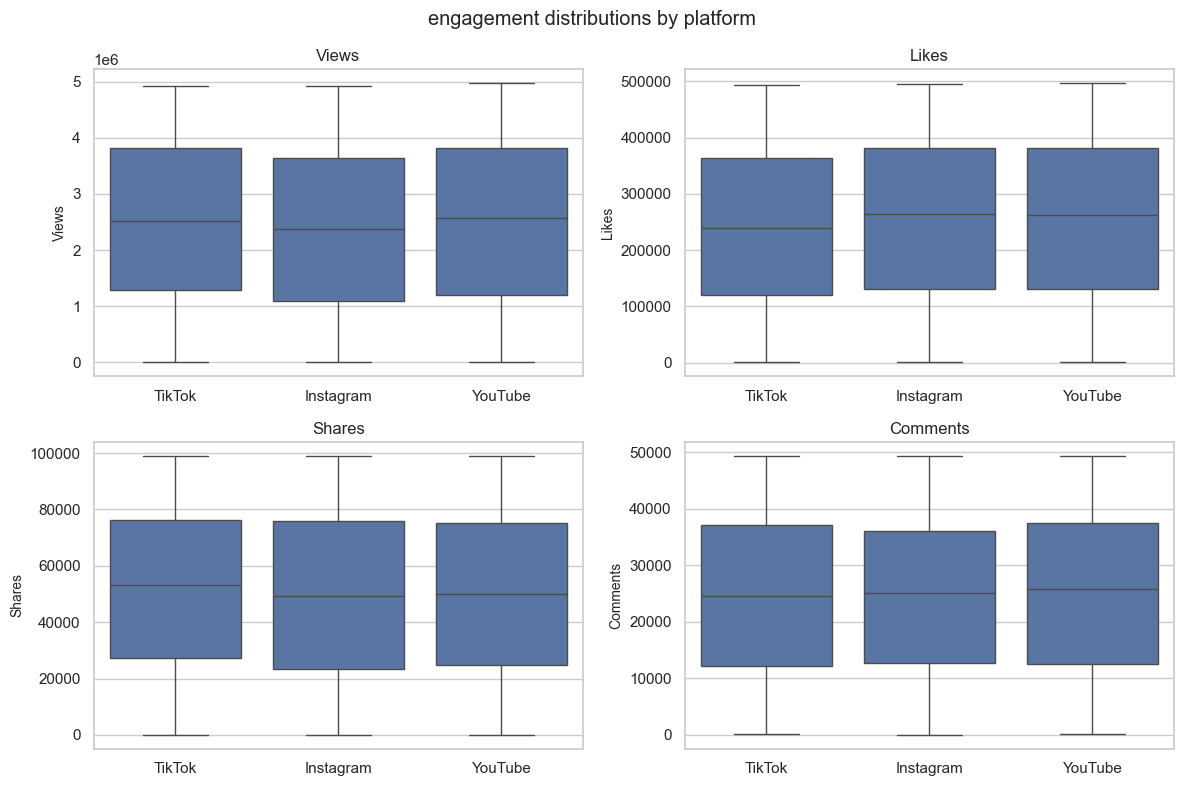

In [118]:
#boxplots for engagement metrics
metrics = ["Views", "Likes", "Shares", "Comments"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

fig.suptitle("engagement distributions by platform")

for ax, m in zip(axes.flatten(), metrics):
    sns.boxplot(data=df, x="Platform", y=m, ax=ax, showfliers=False)
    
    ax.set_title(m)
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

#### 5.2 Engagement Rate Distribution (Viral vs Non-Viral)

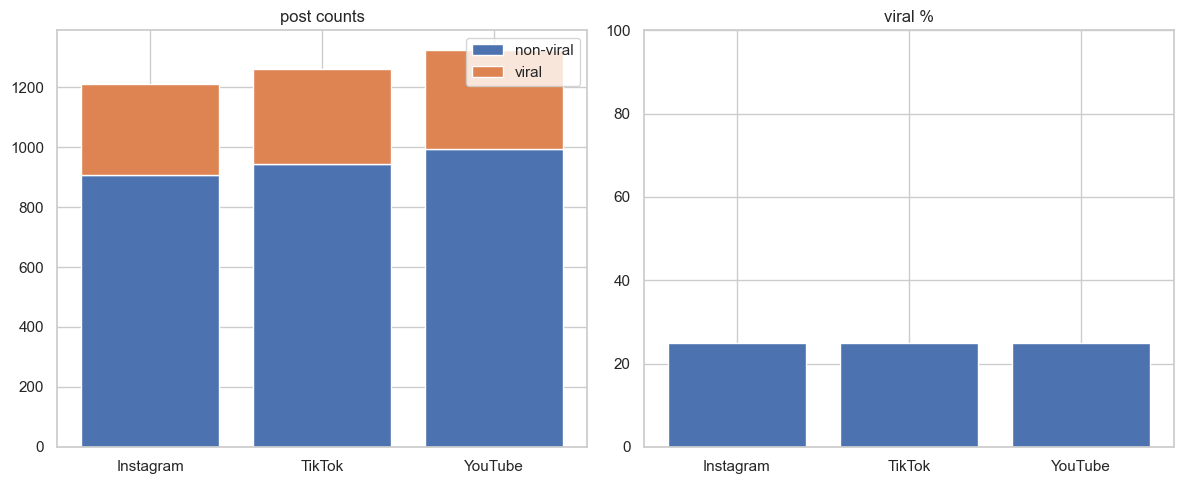

In [119]:

# get counts
summary = df.groupby("Platform")["Viral"].agg(["sum", "count"]).reset_index()
summary.columns = ["Platform", "viral_count", "total"]

# calculate extra columns
summary["nonviral"] = summary["total"] - summary["viral_count"]
summary["viral_pct"] = summary["viral_count"] / summary["total"] * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# plot counts
x = range(len(summary))

ax1.bar(x, summary["nonviral"], label="non-viral")
ax1.bar(x, summary["viral_count"], bottom=summary["nonviral"], label="viral")

ax1.set_xticks(list(x))
ax1.set_xticklabels(summary["Platform"])
ax1.set_title("post counts")
ax1.legend()

# plot percentages
ax2.bar(summary["Platform"], summary["viral_pct"])
ax2.set_title("viral %")
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.show()

##### 5.3 Engagement Rate Distribution: Viral vs Non-Viral — Histogram


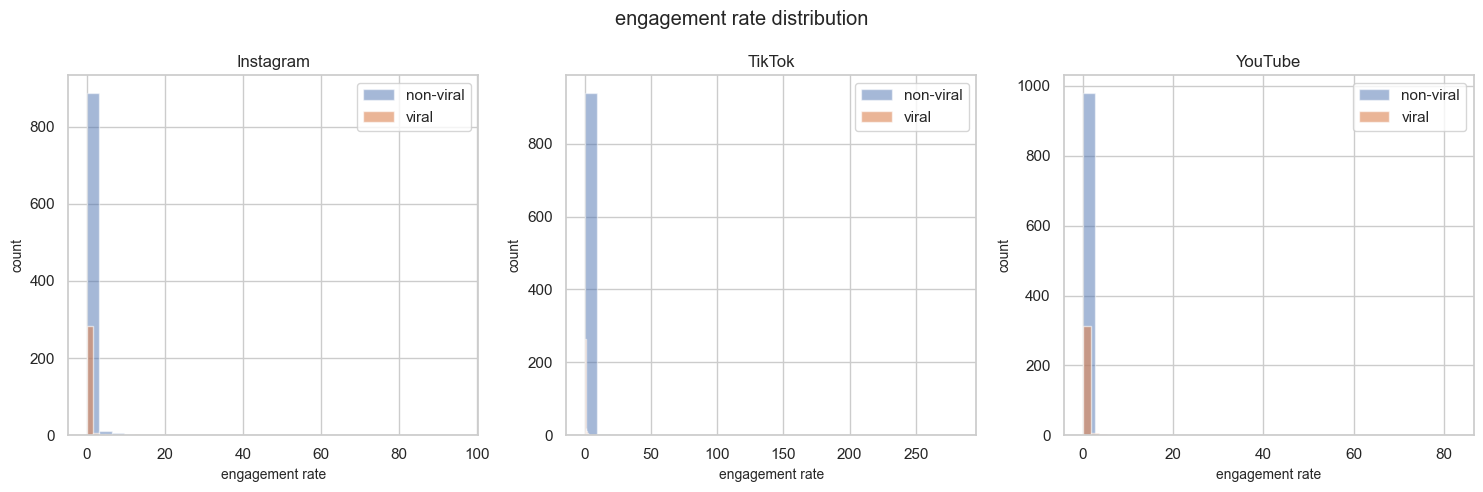

In [120]:

platforms = ["Instagram", "TikTok", "YouTube"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("engagement rate distribution")

for ax, p in zip(axes, platforms):
    temp = df[df["Platform"] == p]

    non_v = temp[temp["Viral"] == 0]["Engagement_Rate"]
    v = temp[temp["Viral"] == 1]["Engagement_Rate"]

    ax.hist(non_v, bins=30, alpha=0.5, label="non-viral")
    ax.hist(v, bins=30, alpha=0.6, label="viral")

    ax.set_title(p)
    ax.set_xlabel("engagement rate")
    ax.set_ylabel("count")
    ax.legend()

plt.tight_layout()
plt.show()

#### 5.4 correlation heatmap

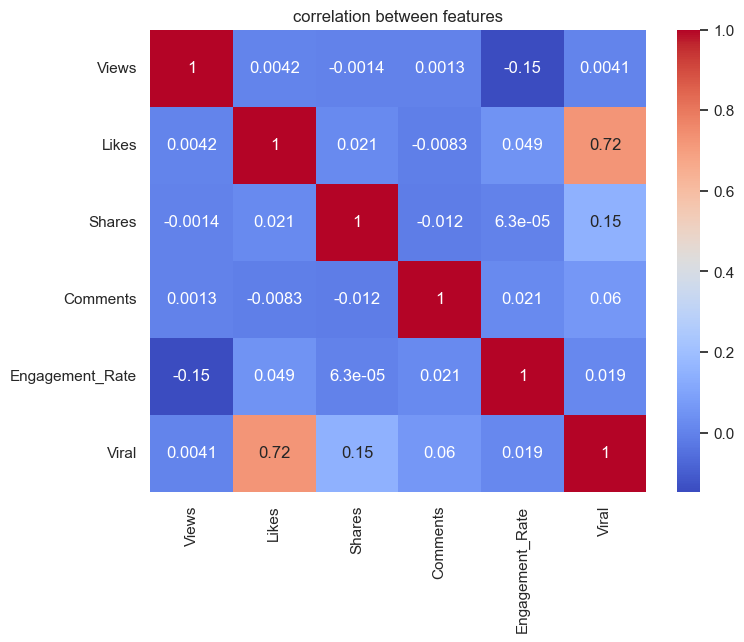

In [121]:
#only use main features instead of derived ones

cols = ["Views", "Likes", "Shares", "Comments", "Engagement_Rate", "Viral"]
corr = df[cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("correlation between features")

plt.show()

#### 5.5: Average Engagement Score by Content Type & Platform: Bar Chart

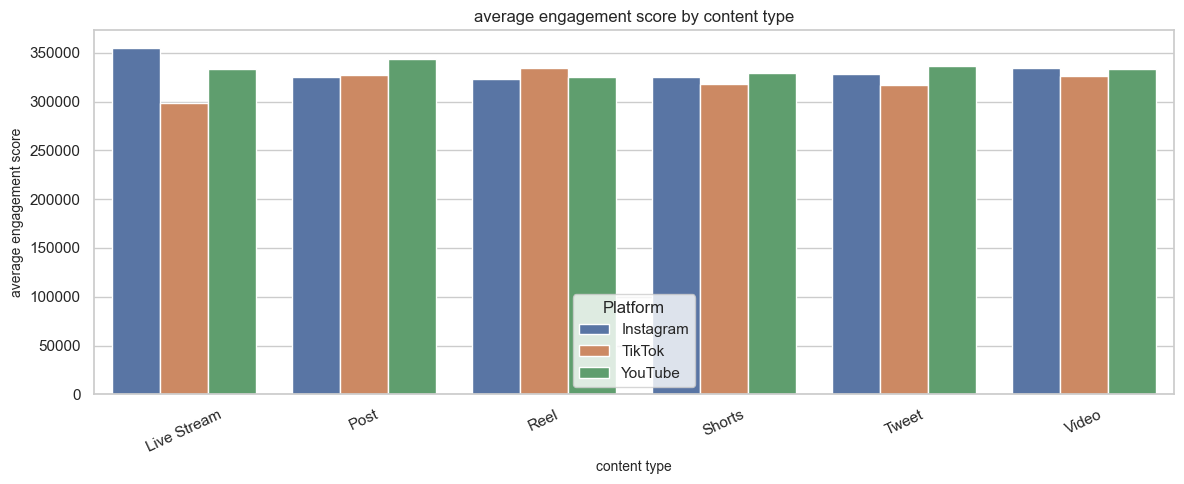

In [122]:

ct_summary = df.groupby(["Content_Type", "Platform"])["Engagement_Score"].mean()
ct_summary = ct_summary.reset_index()

plt.figure(figsize=(12, 5))
sns.barplot(
    data=ct_summary,
    x="Content_Type",
    y="Engagement_Score",
    hue="Platform"
)
plt.title("average engagement score by content type")
plt.xlabel("content type")
plt.ylabel("average engagement score")

plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

#### 5.6: Average Engagement by Region

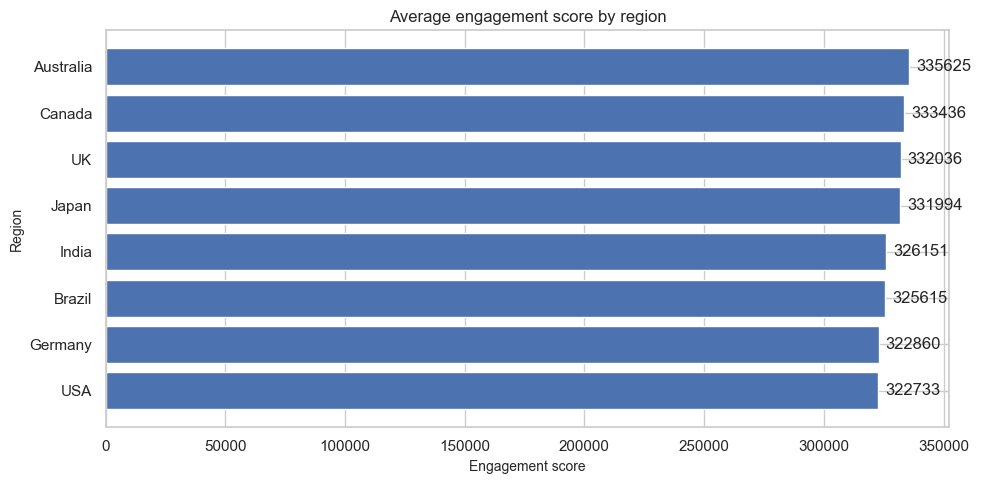

In [123]:

region_avg = df.groupby("Region")["Engagement_Score"].mean()
region_avg = region_avg.sort_values(ascending=False)

plt.figure(figsize=(10, 5))

bars = plt.barh(region_avg.index, region_avg.values)

plt.title("Average engagement score by region")
plt.xlabel("Engagement score")
plt.ylabel("Region")

plt.gca().invert_yaxis()

#numbers next to all of the bars
for i, v in enumerate(region_avg.values):
    plt.text(v + 3000, i, str(int(v)), va='center')

plt.tight_layout()
plt.show()

#### 5.7: Top 10 Hashtags by Average Engagement Score: Horizontal Bar Chart

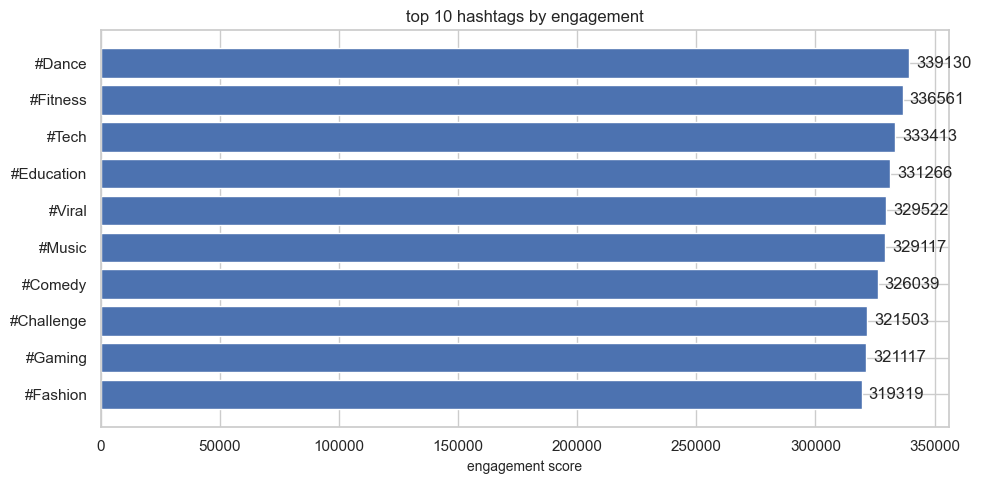

In [124]:

top_tags = df.groupby("Hashtag")["Engagement_Score"].mean()
top_tags = top_tags.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
bars = plt.barh(top_tags.index, top_tags.values)

plt.title("top 10 hashtags by engagement")
plt.xlabel("engagement score")
plt.gca().invert_yaxis()

#add the numbers
for i, v in enumerate(top_tags.values):
    plt.text(v + 3000, i, str(int(v)), va='center')

plt.tight_layout()
plt.show()

#### 5.8: Engagement Score vs Engagement Rate: Scatter Plot (Viral vs Non-Viral)

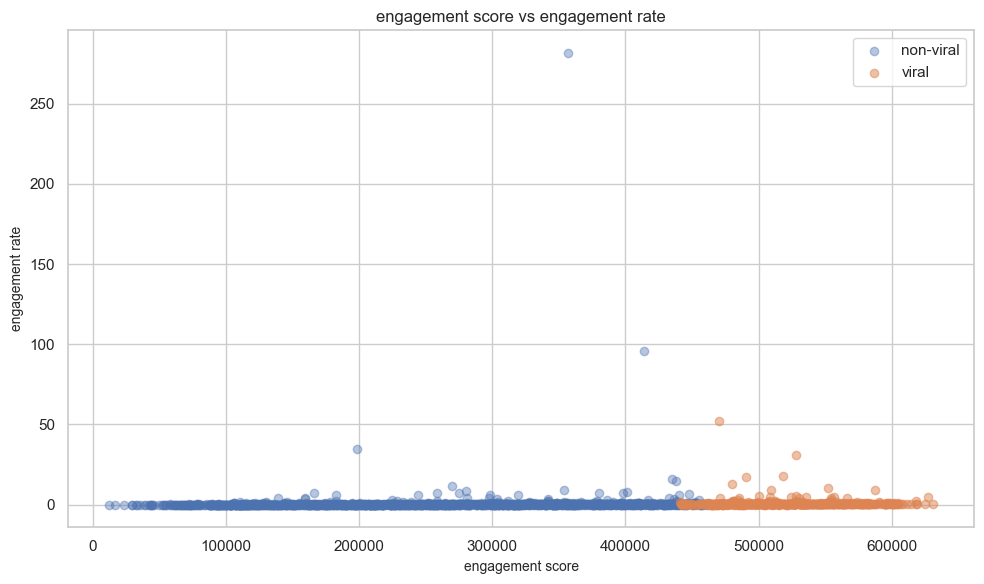

In [125]:
sample = df.sample(n=min(2000, len(df)), random_state=42)
plt.figure(figsize=(10, 6))

# split viral vs non-viral
non_v = sample[sample["Viral"] == 0]
v = sample[sample["Viral"] == 1]
# scatter plots
plt.scatter(non_v["Engagement_Score"], non_v["Engagement_Rate"],
            alpha=0.4, label="non-viral")
plt.scatter(v["Engagement_Score"], v["Engagement_Rate"],
            alpha=0.5, label="viral")

plt.xlabel("engagement score")
plt.ylabel("engagement rate")
plt.title("engagement score vs engagement rate")

plt.legend()
plt.tight_layout()
plt.show()

## 6. Platform-Specific Model Training
 
3 model types: 
- **Logistic Regression**: easy to interpret
- **Random Forest**:  handles more complex patterns in the data
- **XGBoost**: gradient boosting for best accuracy

We build separate models per platform because the drivers of virality differ across TikTok, Instagram, and YouTube. A model trained on TikTok data may fail on YouTube because the engagement mechanisms are fundamentally different.

For evaluation we used 
- 70/30 stratified split 
-  5-fold cross-validation.

In [126]:
# features for the  model
# We exclude Engagement_Score, Engagement_Rate, and all ratio features 
# since they are derived from the same raw metrics
# that are used to define the viral label (top 25% Engagement_Score per platform).
# If we were to include them would then there would be  data leakage.

remove_cols = [
    "Viral",
    "Engagement_Score",
    "Engagement_Rate",
    "Like_to_View",
    "Share_to_View",
    "Comment_to_View",
    "Share_to_Like",
    "Platform",
    "Post_ID",
    "Post_Date",
    "Hashtag",
    "Content_Type",
    "Region"
]

num_cols = df.select_dtypes(include=np.number).columns #this keeps only the numeric columns first

#final feature list 
features = []  

for col in num_cols:
    if col not in remove_cols:
        features.append(col)

print("Features Used:", features)

Features Used: ['Views', 'Likes', 'Shares', 'Comments', 'Month', 'DayOfWeek', 'IsWeekend', 'Content_Type_Enc', 'Region_Enc', 'Hashtag_Enc']


In [127]:
# make the models

def build_models():
    models = {}
    # logistic regression (baseline)
    models["Logistic Regression"] = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ])

    #random forest
    models["Random Forest"] = Pipeline([
        ("model", RandomForestClassifier(n_estimators=200, random_state=42))
    ])
    # xgboost (if it works)
    models["XGBoost"] = Pipeline([
       ("model", xgb.XGBClassifier(
            n_estimators=200,
            learning_rate=0.1,
            max_depth=6,
            eval_metric="logloss",
            random_state=42
        ))
    ])

    return models

#cross validation setup
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("Model Blueprints are ready")

Model Blueprints are ready


In [128]:
def build_models():
    models = {}

    models["Logistic Regression"] = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ])

    models["Random Forest"] = Pipeline([
        ("model", RandomForestClassifier(n_estimators=200, random_state=42))
    ])

    return models

## 7. Model Evaluation & Comparison

In [129]:

all_results = {}
for platform in PLATFORMS:
    print("\n" + "=" * 45)
    print("platform:", platform)
    print("=" * 45)

    sub = df[df["Platform"] == platform].copy()
    X = sub[FEATURE_COLS].fillna(0)
    y = sub["Viral"]

    print("samples:", len(sub), "| viral:", int(y.sum()), f"({y.mean()*100:.1f}%)")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.30,
        random_state=RANDOM_STATE,
        stratify=y
     )
    platform_results = {}
    models = build_models()

    for model_name in models:
        model = models[model_name]
        cv_scores = cross_validate(
            model,
            X_train,
            y_train,
            cv=CV,
            scoring=["accuracy", "f1", "roc_auc"]
        )


        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

        metrics = {
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "f1": f1_score(y_test, y_pred, zero_division=0),
            "roc_auc": roc_auc_score(y_test, y_prob)
        }
        cv_auc = cv_scores["test_roc_auc"].mean()

        print(
            model_name,
            "| acc:", round(metrics["accuracy"], 3),
            "| f1:", round(metrics["f1"], 3),
            "| auc:", round(metrics["roc_auc"], 3),
            "| cv auc:", round(cv_auc, 3)
        )

        platform_results[model_name] = {
            "pipeline": model,
            "metrics": metrics,
            "cv_auc": cv_auc,
            "y_test": y_test,
            "y_pred": y_pred,
            "y_prob": y_prob
        }
        
    all_results[platform] = platform_results

print("\nall models trained")


platform: Instagram
samples: 1212 | viral: 303 (25.0%)
Logistic Regression | acc: 0.986 | f1: 0.973 | auc: 1.0 | cv auc: 0.999
Random Forest | acc: 0.967 | f1: 0.934 | auc: 0.997 | cv auc: 0.994

platform: TikTok
samples: 1260 | viral: 315 (25.0%)
Logistic Regression | acc: 0.984 | f1: 0.967 | auc: 0.999 | cv auc: 0.999
Random Forest | acc: 0.963 | f1: 0.925 | auc: 0.996 | cv auc: 0.995

platform: YouTube
samples: 1324 | viral: 331 (25.0%)
Logistic Regression | acc: 0.982 | f1: 0.964 | auc: 0.999 | cv auc: 0.999
Random Forest | acc: 0.972 | f1: 0.944 | auc: 0.997 | cv auc: 0.997

all models trained


In [130]:

rows = []

for p in all_results:
    
    models = all_results[p]
    
    for name in models:
        res = models[name]
        m = res["metrics"]
        
        rows.append({
            "Platform": p,
            "Model": name,
            "Accuracy": round(m["accuracy"], 3),
            "Precision": round(m["precision"], 3),
            "Recall": round(m["recall"], 3),
            "F1": round(m["f1"], 3),
            "AUC": round(m["roc_auc"], 3)
        })

summary_df = pd.DataFrame(rows)

summary_df = summary_df.sort_values(["Platform", "AUC"], ascending=[True, False])

print("columns:", summary_df.columns.tolist())
summary_df

columns: ['Platform', 'Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'AUC']


,Platform,Model,Accuracy,Precision,Recall,F1,AUC
0,Instagram,Logistic Regression,0.986,0.967,0.978,0.973,1.000
1,Instagram,Random Forest,0.967,0.934,0.934,0.934,0.997
2,TikTok,Logistic Regression,0.984,0.989,0.947,0.967,0.999
3,TikTok,Random Forest,0.963,0.935,0.915,0.925,0.996
4,YouTube,Logistic Regression,0.982,0.969,0.960,0.964,0.999
5,YouTube,Random Forest,0.972,0.949,0.939,0.944,0.997


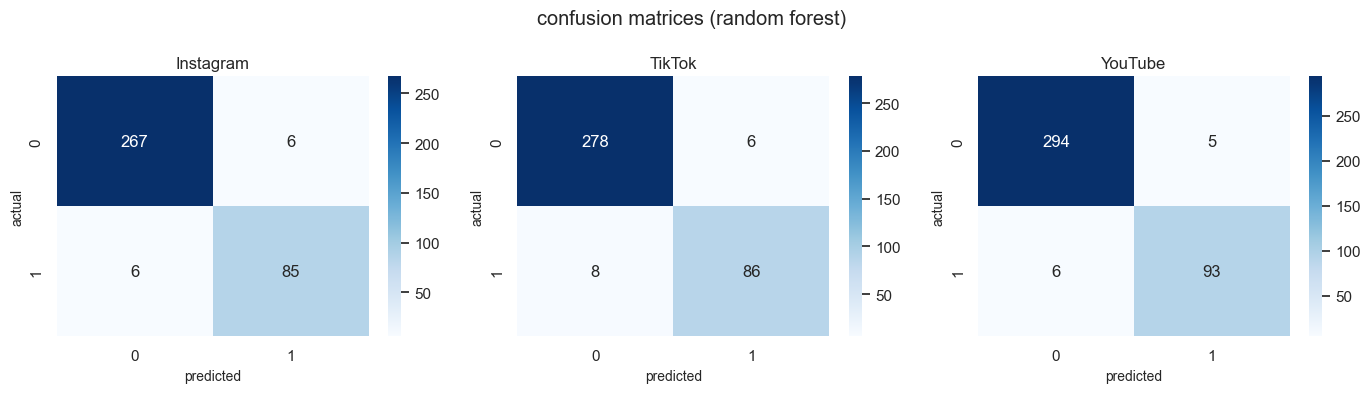

In [131]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("confusion matrices (random forest)")

for i, p in enumerate(PLATFORMS):
    ax = axes[i]
    res = all_results[p]["Random Forest"]   # <-- FIX HERE
    y_true = res["y_test"]
    y_pred = res["y_pred"]
    
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    
    ax.set_title(p)
    ax.set_xlabel("predicted")
    ax.set_ylabel("actual")

plt.tight_layout()
plt.show()

In [132]:
#Detailed classification report per platform (XGBoost)
for platform in PLATFORMS:
    res = all_results[platform]['XGBoost']
    print(f'\n--- {platform} — XGBoost ---')
    print(classification_report(res['y_test'], res['y_pred'],
                                target_names=['Non-Viral', 'Viral']))

KeyError: 'XGBoost'

## 8. Feature Importance & ROC Curves

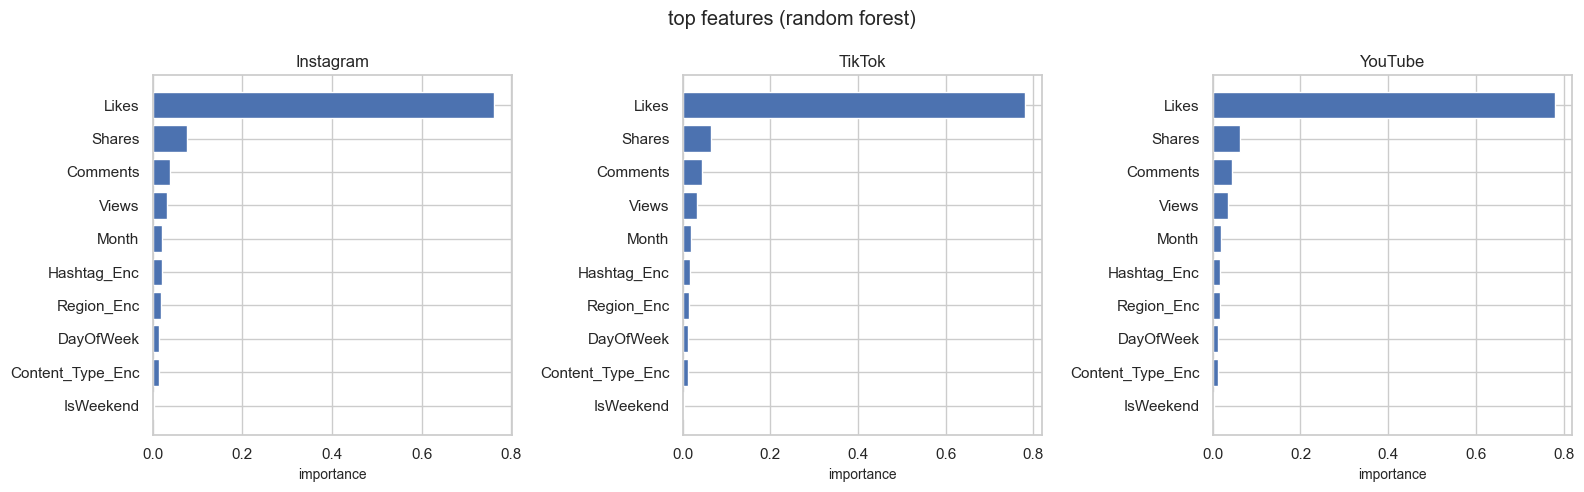

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("top features (random forest)")
for i, p in enumerate(PLATFORMS):
    ax = axes[i]
    pipe = all_results[p]["Random Forest"]["pipeline"]

    importances = pipe.named_steps["model"].feature_importances_
    imp_df = pd.Series(importances, index=FEATURE_COLS)
    imp_df = imp_df.sort_values(ascending=False).head(10)

    ax.barh(imp_df.index[::-1], imp_df.values[::-1])

    ax.set_title(p)
    ax.set_xlabel("importance")

plt.tight_layout()
plt.show()

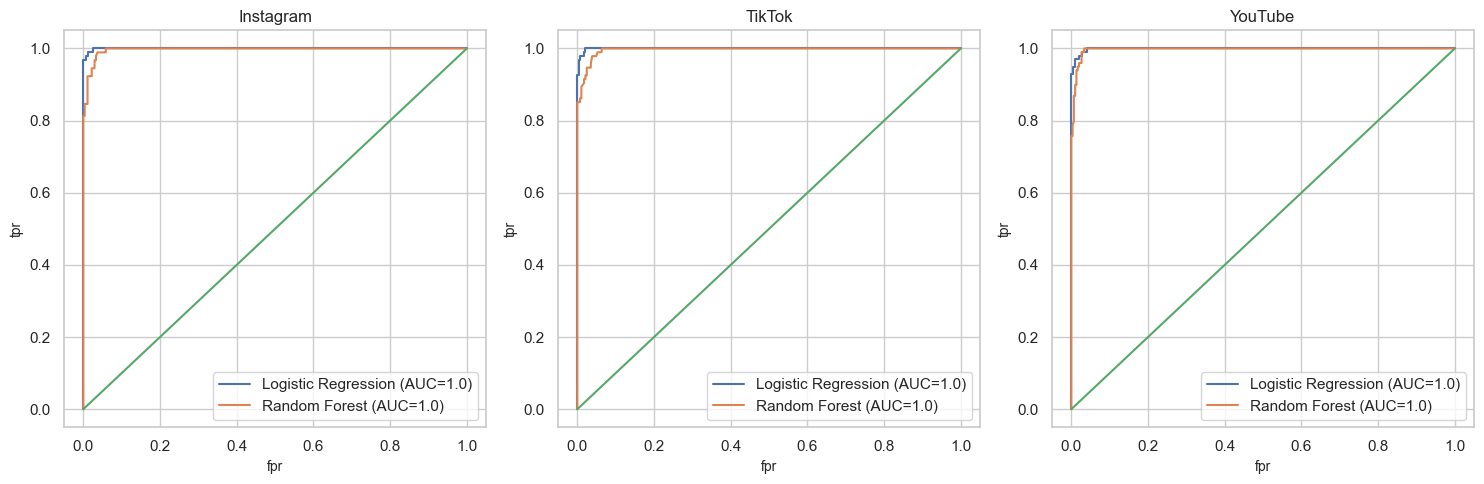

In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, p in enumerate(PLATFORMS):
    ax = axes[i]
    
    for name in all_results[p]:
        res = all_results[p][name]
        fpr, tpr, _ = roc_curve(res["y_test"], res["y_prob"])
        auc = res["metrics"]["roc_auc"]
        ax.plot(fpr, tpr, label=name + " (AUC=" + str(round(auc, 2)) + ")")

    #diagonal line
    ax.plot([0, 1], [0, 1]) 
    ax.set_title(p)
    ax.set_xlabel("fpr")
    ax.set_ylabel("tpr")
    ax.legend()

plt.tight_layout()
plt.show()

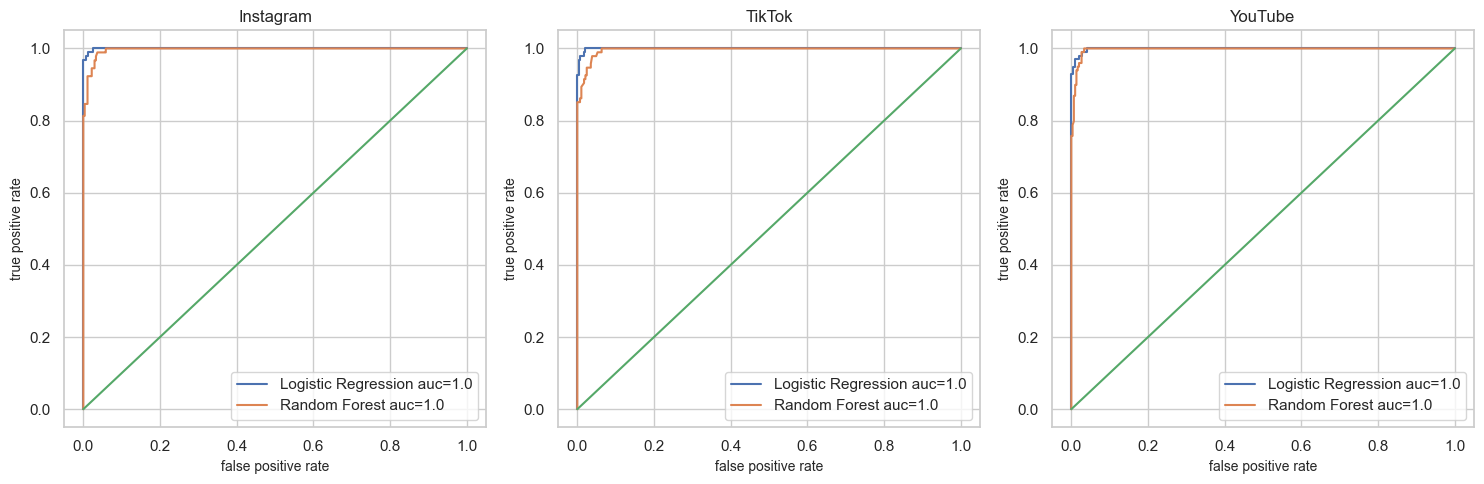

In [ ]:
# roc curves by platform
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, platform in enumerate(PLATFORMS):
    ax = axes[i]

    for model_name in all_results[platform]:
        res = all_results[platform][model_name]
        fpr, tpr, cutoffs = roc_curve(res["y_test"], res["y_prob"])
        auc = res["metrics"]["roc_auc"]
        ax.plot(fpr, tpr, label=model_name + " auc=" + str(round(auc, 2)))
    
    #random guess line
    ax.plot([0, 1], [0, 1])
    ax.set_title(platform)
    ax.set_xlabel("false positive rate")
    ax.set_ylabel("true positive rate")
    ax.legend()

plt.tight_layout()
plt.show()

## 9. Interactive Viral Predictor

Enter a post's details to predict whether it will go viral using the best-performing model per platform.

In [ ]:
# these are maps for the predictor 
platform_map  = {v: i for i, v in enumerate(sorted(df['Platform'].unique()))}
content_map   = {v: i for i, v in enumerate(sorted(df['Content_Type'].unique()))}
region_map    = {v: i for i, v in enumerate(sorted(df['Region'].unique()))}
hashtag_map   = {v: i for i, v in enumerate(sorted(df['Hashtag'].unique()))}

# finding the best model per platform by ROC-AUC
best_models = {}
for platform in PLATFORMS:
    best_name = max(all_results[platform],
                    key=lambda m: all_results[platform][m]['metrics']['roc_auc'])
    best_models[platform] = (best_name, all_results[platform][best_name]['pipeline'])
    print(f'{platform}: best model = {best_name}')

print('\nAvailable platforms :', list(platform_map.keys()))
print('Available content types:', list(content_map.keys()))
print('Available regions   :', list(region_map.keys()))
print('Available hashtags  :', list(hashtag_map.keys()))

Instagram: best model = Logistic Regression
TikTok: best model = Logistic Regression
YouTube: best model = Logistic Regression

Available platforms : ['Instagram', 'TikTok', 'YouTube']
Available content types: ['Live Stream', 'Post', 'Reel', 'Shorts', 'Tweet', 'Video']
Available regions   : ['Australia', 'Brazil', 'Canada', 'Germany', 'India', 'Japan', 'UK', 'USA']
Available hashtags  : ['#Challenge', '#Comedy', '#Dance', '#Education', '#Fashion', '#Fitness', '#Gaming', '#Music', '#Tech', '#Viral']



--- Example 1: High-engagement TikTok video ---
  POST VIRAL PREDICTION  [Logistic Regression]
  Platform      : TikTok
  Content Type  : Video
  Region        : USA
  Hashtag       : #Challenge
  Views         :    4,500,000
  Likes         :      450,000
  Shares        :       85,000
  Comments      :       40,000
-------------------------------------------------------
  Engagement Score       : 575,000
  Platform Viral Threshold: 440,542
  Viral Probability : 99.8%
  Prediction        : >>> VIRAL 🚀 <<<


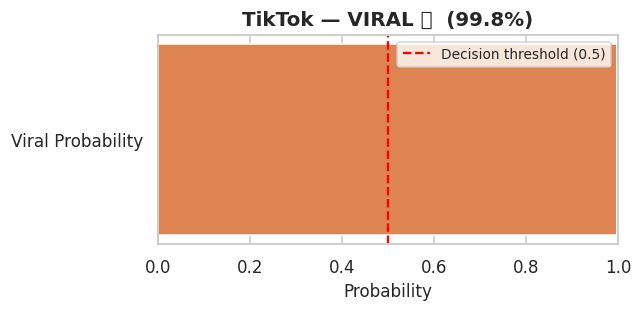


--- Example 2: Low-engagement Instagram post ---
  POST VIRAL PREDICTION  [Logistic Regression]
  Platform      : Instagram
  Content Type  : Post
  Region        : India
  Hashtag       : #Education
  Views         :       10,000
  Likes         :          500
  Shares        :           50
  Comments      :           30
-------------------------------------------------------
  Engagement Score       : 580
  Platform Viral Threshold: 461,652
  Viral Probability : 0.0%
  Prediction        : >>> Not Viral <<<


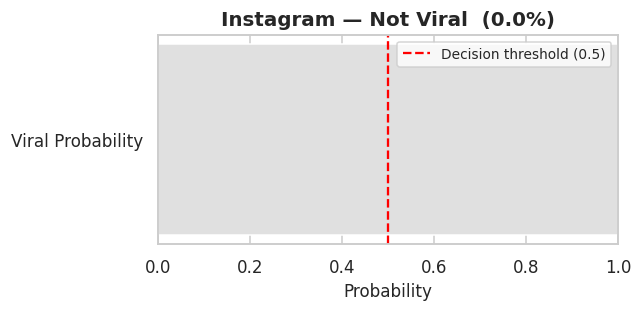

{'label': 'Not Viral', 'probability': np.float64(0.0), 'engagement_score': 580}

In [ ]:
def predict_viral(
    views: int,
    likes: int,
    shares: int,
    comments: int,
    platform: str      = 'TikTok',
    content_type: str  = 'Video',
    region: str        = 'USA',
    hashtag: str       = '#Challenge',
    month: int         = 6,
    day_of_week: int   = 2
):
    """
    Predict whether a social media post will go viral.
    Uses the best-performing model for the specified platform.
    """
    if platform not in PLATFORMS:
        print(f'Platform must be one of {PLATFORMS}')
        return None

    best_name, best_pipe = best_models[platform]

    safe_views       = views if views > 0 else 1
    engagement_score = likes + comments + shares
    is_weekend       = int(day_of_week >= 5)

    content_enc  = content_map.get(content_type, 0)
    region_enc   = region_map.get(region, 0)
    hashtag_enc  = hashtag_map.get(hashtag, 0)

    # Must match FEATURE_COLS order exactly
    row = pd.DataFrame([{
        'Views': views, 'Likes': likes, 'Shares': shares, 'Comments': comments,
        'Content_Type_Enc': content_enc,
        'Region_Enc': region_enc,
        'Hashtag_Enc': hashtag_enc,
        'Month': month,
        'DayOfWeek': day_of_week,
        'IsWeekend': is_weekend
    }])[FEATURE_COLS]

    prob  = best_pipe.predict_proba(row)[0][1]
    label = 'VIRAL 🚀' if prob >= 0.5 else 'Not Viral'

    # Get platform-specific viral threshold
    platform_threshold = df[df['Platform']==platform]['Engagement_Score'].quantile(VIRAL_PERCENTILE/100)

    print('=' * 55)
    print(f'  POST VIRAL PREDICTION  [{best_name}]')
    print('=' * 55)
    print(f'  Platform      : {platform}')
    print(f'  Content Type  : {content_type}')
    print(f'  Region        : {region}')
    print(f'  Hashtag       : {hashtag}')
    print(f'  Views         : {views:>12,}')
    print(f'  Likes         : {likes:>12,}')
    print(f'  Shares        : {shares:>12,}')
    print(f'  Comments      : {comments:>12,}')
    print('-' * 55)
    print(f'  Engagement Score       : {engagement_score:,}')
    print(f'  Platform Viral Threshold: {platform_threshold:,.0f}')
    print('=' * 55)
    print(f'  Viral Probability : {prob*100:.1f}%')
    print(f'  Prediction        : >>> {label} <<<')
    print('=' * 55)

    # Probability bar chart
    fig, ax = plt.subplots(figsize=(6, 3))
    bar_color = '#DD8452' if prob >= 0.5 else '#4C72B0'
    ax.barh(['Viral Probability'], [prob], color=bar_color, height=0.4)
    ax.barh(['Viral Probability'], [1 - prob], left=[prob],
            color='#e0e0e0', height=0.4)
    ax.axvline(0.5, color='red', linestyle='--', linewidth=1.5, label='Decision threshold (0.5)')
    ax.set_xlim(0, 1)
    ax.set_xlabel('Probability')
    ax.set_title(f'{platform} — {label}  ({prob*100:.1f}%)', fontweight='bold')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

    return {'label': label, 'probability': round(prob, 4),
            'engagement_score': engagement_score}


# --- Example predictions ---
print('\n--- Example 1: High-engagement TikTok video ---')
predict_viral(views=4_500_000, likes=450_000, shares=85_000, comments=40_000,
              platform='TikTok', content_type='Video', region='USA',
              hashtag='#Challenge', month=7, day_of_week=6)

print('\n--- Example 2: Low-engagement Instagram post ---')
predict_viral(views=10_000, likes=500, shares=50, comments=30,
              platform='Instagram', content_type='Post', region='India',
              hashtag='#Education', month=3, day_of_week=1)

## Summary

| Section | Key Finding |
|---------|-------------|
| **Data** | 5,000 posts across TikTok, Instagram, YouTube (2022–2023) |
| **Viral Label** | Top 25% Engagement Score **per platform** — avoids global threshold bias |
| **Features** | Raw metrics + temporal (Month, DayOfWeek, IsWeekend) + categorical (Content, Region, Hashtag) |
| **Leakage Issue** | Ratio features (Engagement_Rate, Like_to_View etc.) excluded — derived from same metrics as label |
| **AUC Limitation** | Near-perfect AUC due to synthetic dataset — no natural noise in engagement numbers |
| **Best Models** | XGBoost / Random Forest dominate across all platforms |
| **Key Insight** | Platform-specific models outperform a single global model — virality drivers differ per platform |
